DSCI 552 Final Project

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

In [39]:
import cv2
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IPipeline # for SMOTE / 1.b.iv
from imblearn.under_sampling import RandomUnderSampler
from itertools import combinations
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import re
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.datasets import make_classification, make_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV, RidgeCV, LassoCV
from sklearn.metrics import silhouette_score, hamming_loss, RocCurveDisplay, roc_auc_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score, RepeatedKFold, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline as SPipeline # for StandardScaler / 1.b.iii
from sklearn.preprocessing import StandardScaler, label_binarize, OneHotEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

#from skmultilearn.problem_transform import LabelPowerset
import statsmodels.api as sm
import statsmodels.formula.api as smf

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import xgboost as xgb

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
data_path = "/content/drive/MyDrive/defungi"

Objective:
- Trying to build a classifier that distinguishes images of FIVE types of waste

Data Exploration and Pre-Processing
- Images are numbered in each folder
- Select FIRST 80% of the images in EACH FOLDER as your TRAINING set
- - Use the rest as the TEST set
  - Can you encode classes using one-hot encoding
- In case all the images do not have the same size, ZERO-PAD or RESIZE the images in your dataset
- - This can be done using various tools, including OpenCV

In [26]:
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224

In [27]:
# 80% Training, 20% Testing
    # Will take the 20% Validation Set from the training set now as well
    # So for the 80% training: 64% for actual training, 16% for VS

In [28]:
defungi_path = Path(data_path)
waste_class_names = ["C1", "C2", "C3", "C4", "C5"]

In [29]:
# to make sure the images get sorted correctly
    # aka: making sure H1_100a_3.jpg comes before H1_101a_1.jpg, etc.
def natural_sorting(path_to_image):
    return [
        int(c) if c.isdigit() else c.lower()
        for c in re.split(r'(\d+)', path_to_image.name)
    ]

In [30]:
training_paths = []
training_labels = []

testing_paths = []
testing_labels = []

valset_paths = []
valset_labels = []

# parallel lists: ex -> training_paths has the image paths, training_labels has the class labels
# I'm keeping these separate cause I don't want to deal with a dictionary


In [31]:
cw_index = 0
for waste_class in waste_class_names:
    waste_class_folder = defungi_path / waste_class
    # makes the path to the inner folder from the outer defungi folder
        # so now "../data/defungi/C1" for example

    image_files_list = list(waste_class_folder.glob("*.jpg"))
    sorted_filenames = sorted(image_files_list, key=natural_sorting) # NATURALLY sort all the image files

    tt_split_index = int(0.80 * len(sorted_filenames))

    # training + validation all together first
    training_validation_set = sorted_filenames[:tt_split_index]
    # testing set, can leave this alone
    testing_image_paths = sorted_filenames[tt_split_index:]

    # splitting into true training set and true validation set
    # random 20% of train+val set will go to validation_image_paths, other 80% to training
    training_image_paths, validation_image_paths = train_test_split(training_validation_set, test_size=0.20, random_state=42, shuffle=True)

    #####

    training_paths.extend(training_image_paths)
    train_class_label_list = [cw_index] * len(training_image_paths)
    training_labels.extend(train_class_label_list)

    testing_paths.extend(testing_image_paths)
    test_class_label_list = [cw_index] * len(testing_image_paths)
    testing_labels.extend(test_class_label_list)

    valset_paths.extend(validation_image_paths)
    val_class_label_list = [cw_index] * len(validation_image_paths)
    valset_labels.extend(val_class_label_list)

    cw_index+=1


In [32]:
# resnet50, resnet101, efficientnetb0, and vgg16 take: 224 x 224 picels with 3 color channels
    # resnet + efficientnet -> expect RGB
    # vgg16 -> expects BGR
        # preprocess will convert back later, to make simple going to convert all to RGB now
def resize_zeropad_images(image_paths):
    fixed_images = []
    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Could not load image")

        # convert all to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        og_h, og_w = image.shape[:2]

        scale = min(IMAGE_HEIGHT / og_h, IMAGE_WIDTH / og_w)

        # new dimensions
        new_w = int(og_w * scale)
        new_h = int(og_h * scale)

        # resize image
        resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

        top = (IMAGE_HEIGHT - new_h) // 2
        bottom = IMAGE_HEIGHT - new_h - top
        left = (IMAGE_WIDTH - new_w) // 2
        right = IMAGE_WIDTH - new_w - left

        # zero padding image
        padded_image = cv2.copyMakeBorder(
            resized_image, top, bottom, left, right,
            borderType=cv2.BORDER_CONSTANT,
            value=[0, 0, 0]
        )

        fixed_images.append(padded_image)

    return fixed_images


In [33]:
X_train = np.array(resize_zeropad_images(training_paths))
X_test= np.array(resize_zeropad_images(testing_paths))
X_val = np.array(resize_zeropad_images(valset_paths))

encoder = OneHotEncoder(sparse_output=False)

Y_train = encoder.fit_transform(np.array(training_labels).reshape(-1, 1))
Y_test = encoder.fit_transform(np.array(testing_labels).reshape(-1, 1))
Y_val = encoder.fit_transform(np.array(valset_labels).reshape(-1, 1))

Transfer Learning i
- Transfer learning for small image datasets
- - uses deep learning models that are trained on large datasets as feature extractors
  - these deep networks have learned to extract meaningful features from an image using their layers, thos features can be used in learning other tasks
- Usually last / last few layers of the pre-trained network are removed, and the response of the layer before the removed layers to the images in the new dataset is used as a feature vector to train one more multiple replacement layers
- Will use pre-trained models: ResNet50, ResNet101, EfficientNetB0, and VGG16
- - will only train LAST fully connected layer, and will FREEZE all layers before them (we do not change their parameters during training)
  - will use the outputs of the penultimate layer in the original pre-trained model as the features extracted from each image

Transfer Learning ii
- To perform empirical regularization, crop, randomly zoom, rotate, flip, contrast, and translate images in your training set for image augmentation
- - can use various tools to do this (including OpenCV)

In [34]:
data_augmentation = tf.keras.Sequential([
    layers.RandomCrop(180, 180),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.Resizing(224, 224)
])
# need resize at end because need 224x224

In [35]:
# ResNet50
# load base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# freeze all layers in base model
base_model.trainable = False
# build final model
inputs = keras.Input(shape=(224, 224, 3))
# augment images
x = data_augmentation(inputs)
# specific preprocess for model to make images be correct for model
x = resnet_preprocess(x)
# pass augmented / pre-processed images through ResNet
x = base_model(x, training=False)
    # false keeps BatchNormalization in inference mode
x = layers.GlobalAveragePooling2D()(x)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
# ReLu activation functions in dense layer
# L2 regularization
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    # 256 neurons was recomended for the training size and number of classes
    # 0.001 as a middle ground penalty
# batch normalization
x = layers.BatchNormalization()(x)
# dropout rate of 20%
x = layers.Dropout(0.2)(x)
# softmax layer -> needs to be last / last layer
outputs = layers.Dense(5, activation="softmax")(x)

Transfer Learning iii
- Use ReLu activation functions in the last layer and softmax layer, along with L2 regularization, batch normalization, dropout rate of 20% as well as ADAM optimizer
- Use multinomial cross entropy loss
- You can try any batch size, but a batch size of 5 seems reasonable

In [37]:
# ADAM optimizer
# multinomial cross entropy loss
resnet50_fm = keras.Model(inputs=inputs, outputs=outputs)
resnet50_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

Transfer Learning iv
- Train the networs for at least 50 epochs (preferably 100 epochs) and perform early stopping using the validation set
- Use a randomly selected subset of 20% of each class as the validation set
- Keep the network parameters that have the lowest validation error
- Plot the training and validation errors vs. epochs

In [40]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
# lowest validation error
# patience 10 -> good for deep networks like ResNet50

checkpoint = ModelCheckpoint(
    "best_resnet50.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_resnet50 = resnet50_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6575 - loss: 0.9884
Epoch 1: val_loss improved from None to 0.81535, saving model to best_resnet50.weights.h5

Epoch 1: finished saving model to best_resnet50.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.6525 - loss: 1.0008 - val_accuracy: 0.7397 - val_loss: 0.8153
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6668 - loss: 0.9731
Epoch 2: val_loss improved from 0.81535 to 0.78567, saving model to best_resnet50.weights.h5

Epoch 2: finished saving model to best_resnet50.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 46s 40ms/step - accuracy: 0.6727 - loss: 0.9503 - val_accuracy: 0.7397 - val_loss: 0.7857
Epoch 3/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6598 - loss: 0.9507
Epoch 3: val_loss did not improve from 0.78567
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.6624 - loss: 0.9689 - val_accuracy: 0.7308 - val_loss: 0.8279
Epoch 4/100
1166/

In [44]:
# RESNET101 NOW
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = resnet_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

resnet101_fm = keras.Model(inputs=inputs, outputs=outputs)
resnet101_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_resnet101.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_resnet101 = resnet101_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5524 - loss: 1.5077
Epoch 1: val_loss improved from None to 0.86271, saving model to best_resnet101.weights.h5

Epoch 1: finished saving model to best_resnet101.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 94s 69ms/step - accuracy: 0.6075 - loss: 1.2621 - val_accuracy: 0.7473 - val_loss: 0.8627
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6626 - loss: 1.0520
Epoch 2: val_loss improved from 0.86271 to 0.82786, saving model to best_resnet101.weights.h5

Epoch 2: finished saving model to best_resnet101.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 74s 63ms/step - accuracy: 0.6581 - loss: 1.0321 - val_accuracy: 0.7390 - val_loss: 0.8279
Epoch 3/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6623 - loss: 1.0143
Epoch 3: val_loss improved from 0.82786 to 0.80897, saving model to best_resnet101.weights.h5

Epoch 3: finished saving model to

In [46]:
# EfficientNetB0 NOW
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = effnet_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

effnet_fm = keras.Model(inputs=inputs, outputs=outputs)
effnet_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_effnet.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_effnet = effnet_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5398 - loss: 1.6015
Epoch 1: val_loss improved from None to 1.05510, saving model to best_effnet.weights.h5

Epoch 1: finished saving model to best_effnet.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.5834 - loss: 1.4023 - val_accuracy: 0.6986 - val_loss: 1.0551
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6249 - loss: 1.2008
Epoch 2: val_loss improved from 1.05510 to 0.97389, saving model to best_effnet.weights.h5

Epoch 2: finished saving model to best_effnet.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.6357 - loss: 1.1535 - val_accuracy: 0.7082 - val_loss: 0.9739
Epoch 3/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6362 - loss: 1.1087
Epoch 3: val_loss did not improve from 0.97389
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.6292 - loss: 1.1072 - val_accuracy: 

In [48]:
# VGG16 NOW
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = vgg_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

vgg_fm = keras.Model(inputs=inputs, outputs=outputs)
vgg_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_vgg.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_vgg = vgg_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5327 - loss: 1.4541
Epoch 1: val_loss improved from None to 1.11061, saving model to best_vgg.weights.h5

Epoch 1: finished saving model to best_vgg.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.5803 - loss: 1.2821 - val_accuracy: 0.6637 - val_loss: 1.1106
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6310 - loss: 1.0875
Epoch 2: val_loss did not improve from 1.11061
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - accuracy: 0.6314 - loss: 1.0752 - val_accuracy: 0.6418 - val_loss: 1.1274
Epoch 3/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6388 - loss: 1.0258
Epoch 3: val_loss improved from 1.11061 to 0.92287, saving model to best_vgg.weights.h5

Epoch 3: finished saving model to best_vgg.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 53s 46ms/step - accuracy: 0.6383 - loss: 1.0188 - val_accuracy: 0.6705 - val

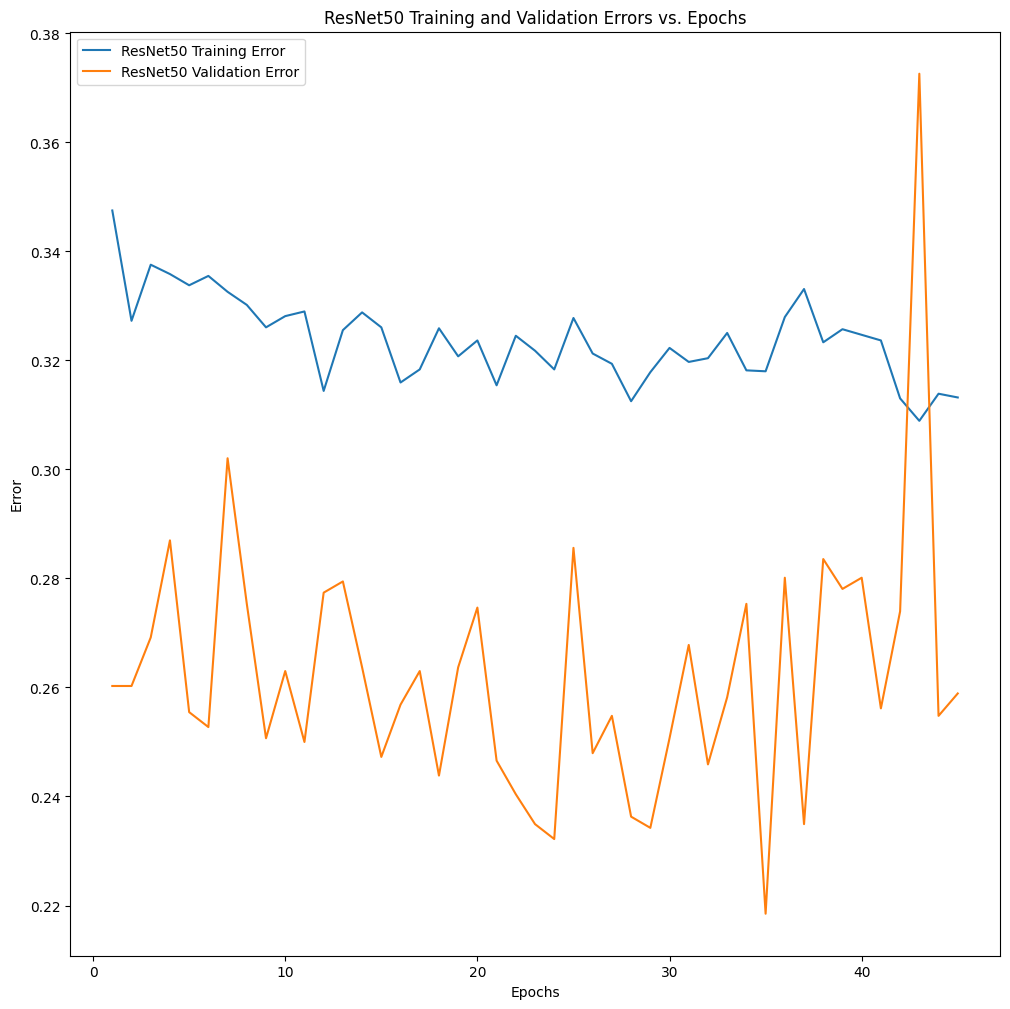

183/183 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step
ResNet50 TRAINING Scores:
	Precision: 0.7724605223162833
	Recall: 0.7746140651801029
	F1 Score: 0.7595179408631597
	AUC: 0.9017638248914632
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step
ResNet50 TESTING Scores:
	Precision: 0.579191191316161
	Recall: 0.6047149122807017
	F1 Score: 0.5597242347308073
	AUC: 0.7933116476075919
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step
ResNet50 VALIDATION Scores:
	Precision: 0.779846602067168
	Recall: 0.7815068493150685
	F1 Score: 0.7682081905207583
	AUC: 0.9000116833198943


In [42]:
# ResNet50 plot training and validation errors vs. epochs
resnet50_train_acc = np.array(history_resnet50.history['accuracy'])
resnet50_val_acc = np.array(history_resnet50.history['val_accuracy'])
resnet50_train_error = 1 - resnet50_train_acc
resnet50_val_error = 1 - resnet50_val_acc
resnet50_epochs = np.arange(1, len(resnet50_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(resnet50_epochs, resnet50_train_error, label='ResNet50 Training Error')
plt.plot(resnet50_epochs, resnet50_val_error, label='ResNet50 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("ResNet50 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
rn50_Y_train_probs = resnet50_fm.predict(X_train)

rn50_Y_train_true = np.argmax(Y_train, axis=1)
rn50_Y_train_pred = np.argmax(rn50_Y_train_probs, axis=1)

rn50_train_precision = precision_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_recall = recall_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_f1 = f1_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_auc = roc_auc_score(Y_train, rn50_Y_train_probs, average='weighted', multi_class='ovr')

print("ResNet50 TRAINING Scores:")
print(f"\tPrecision: {rn50_train_precision}")
print(f"\tRecall: {rn50_train_recall}")
print(f"\tF1 Score: {rn50_train_f1}")
print(f"\tAUC: {rn50_train_auc}")

# testing Precision, Recall, AUC, F1 Score
rn50_Y_test_probs = resnet50_fm.predict(X_test)

rn50_Y_test_true = np.argmax(Y_test, axis=1)
rn50_Y_test_pred = np.argmax(rn50_Y_test_probs, axis=1)

rn50_test_precision = precision_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_recall = recall_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_f1 = f1_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_auc = roc_auc_score(Y_test, rn50_Y_test_probs, average='weighted', multi_class='ovr')

print("ResNet50 TESTING Scores:")
print(f"\tPrecision: {rn50_test_precision}")
print(f"\tRecall: {rn50_test_recall}")
print(f"\tF1 Score: {rn50_test_f1}")
print(f"\tAUC: {rn50_test_auc}")

# validation Precision, Recall, AUC, F1 Score
rn50_Y_val_probs = resnet50_fm.predict(X_val)

rn50_Y_val_true = np.argmax(Y_val, axis=1)
rn50_Y_val_pred = np.argmax(rn50_Y_val_probs, axis=1)

rn50_val_precision = precision_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_recall = recall_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_f1 = f1_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_auc = roc_auc_score(Y_val, rn50_Y_val_probs, average='weighted', multi_class='ovr')

print("ResNet50 VALIDATION Scores:")
print(f"\tPrecision: {rn50_val_precision}")
print(f"\tRecall: {rn50_val_recall}")
print(f"\tF1 Score: {rn50_val_f1}")
print(f"\tAUC: {rn50_val_auc}")


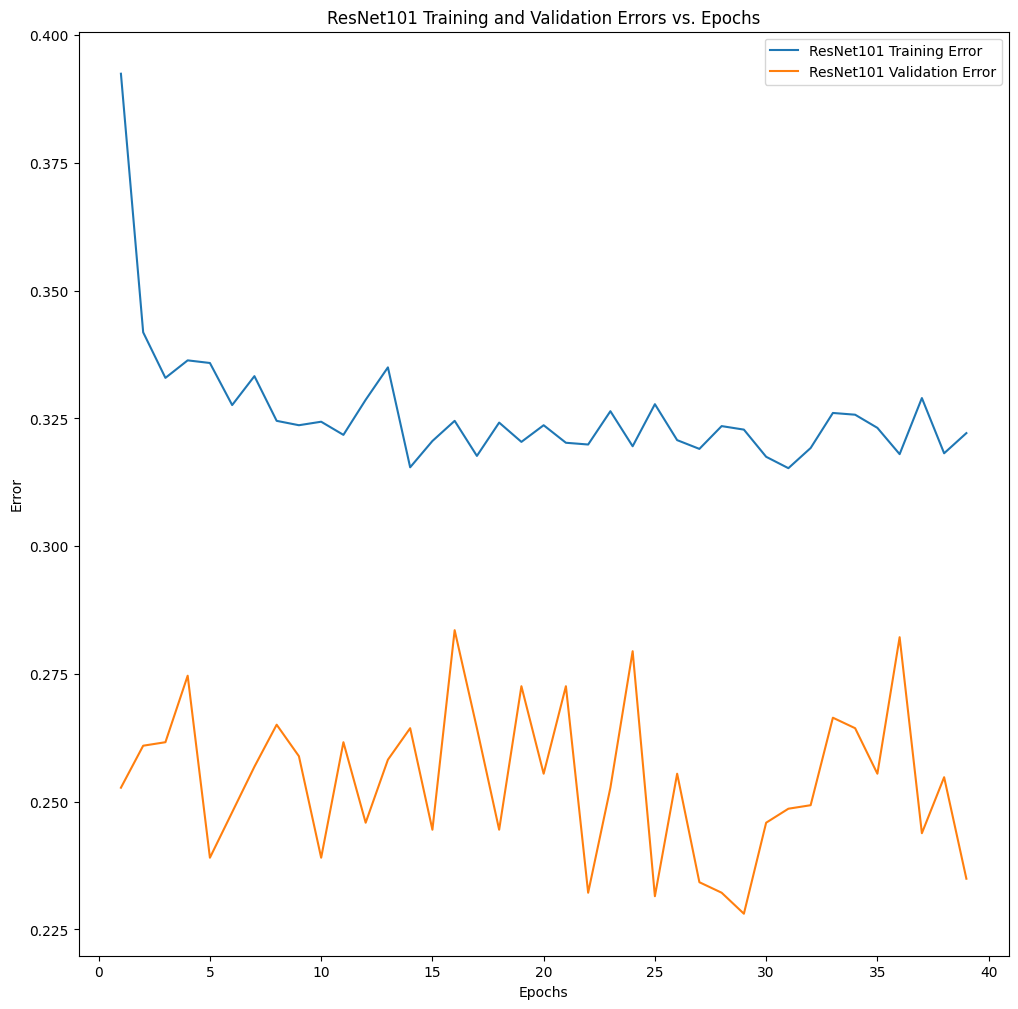

183/183 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step
ResNet101 TRAINING Scores:
	Precision: 0.7546897021997285
	Recall: 0.7586620926243568
	F1 Score: 0.7396084412852695
	AUC: 0.900462095268271
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step
ResNet101 TESTING Scores:
	Precision: 0.6093238238575134
	Recall: 0.6178728070175439
	F1 Score: 0.5785661568189733
	AUC: 0.7997794525018916
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step
ResNet101 VALIDATION Scores:
	Precision: 0.7693636837740535
	Recall: 0.7719178082191781
	F1 Score: 0.7559726569438993
	AUC: 0.9001383640925125


In [45]:
# ResNet101 plot training and validation errors vs. epochs
resnet101_train_acc = np.array(history_resnet101.history['accuracy'])
resnet101_val_acc = np.array(history_resnet101.history['val_accuracy'])
resnet101_train_error = 1 - resnet101_train_acc
resnet101_val_error = 1 - resnet101_val_acc
resnet101_epochs = np.arange(1, len(resnet101_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(resnet101_epochs, resnet101_train_error, label='ResNet101 Training Error')
plt.plot(resnet101_epochs, resnet101_val_error, label='ResNet101 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("ResNet101 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
rn101_Y_train_probs = resnet101_fm.predict(X_train)

rn101_Y_train_true = np.argmax(Y_train, axis=1)
rn101_Y_train_pred = np.argmax(rn101_Y_train_probs, axis=1)

rn101_train_precision = precision_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_recall = recall_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_f1 = f1_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_auc = roc_auc_score(Y_train, rn101_Y_train_probs, average='weighted', multi_class='ovr')

print("ResNet101 TRAINING Scores:")
print(f"\tPrecision: {rn101_train_precision}")
print(f"\tRecall: {rn101_train_recall}")
print(f"\tF1 Score: {rn101_train_f1}")
print(f"\tAUC: {rn101_train_auc}")

# testing Precision, Recall, AUC, F1 Score
rn101_Y_test_probs = resnet101_fm.predict(X_test)

rn101_Y_test_true = np.argmax(Y_test, axis=1)
rn101_Y_test_pred = np.argmax(rn101_Y_test_probs, axis=1)

rn101_test_precision = precision_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_recall = recall_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_f1 = f1_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_auc = roc_auc_score(Y_test, rn101_Y_test_probs, average='weighted', multi_class='ovr')

print("ResNet101 TESTING Scores:")
print(f"\tPrecision: {rn101_test_precision}")
print(f"\tRecall: {rn101_test_recall}")
print(f"\tF1 Score: {rn101_test_f1}")
print(f"\tAUC: {rn101_test_auc}")

# validation Precision, Recall, AUC, F1 Score
rn101_Y_val_probs = resnet101_fm.predict(X_val)

rn101_Y_val_true = np.argmax(Y_val, axis=1)
rn101_Y_val_pred = np.argmax(rn101_Y_val_probs, axis=1)

rn101_val_precision = precision_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_recall = recall_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_f1 = f1_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_auc = roc_auc_score(Y_val, rn101_Y_val_probs, average='weighted', multi_class='ovr')

print("ResNet101 VALIDATION Scores:")
print(f"\tPrecision: {rn101_val_precision}")
print(f"\tRecall: {rn101_val_recall}")
print(f"\tF1 Score: {rn101_val_f1}")
print(f"\tAUC: {rn101_val_auc}")

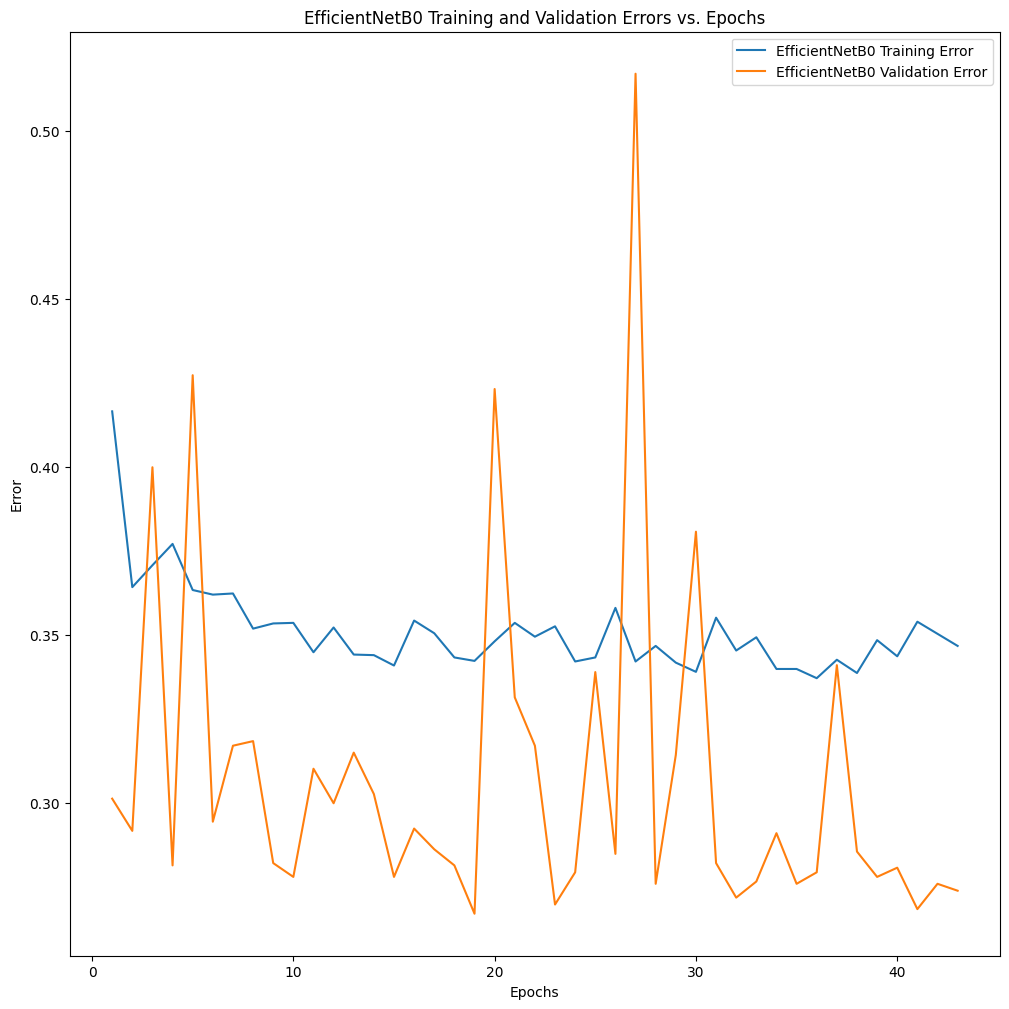

183/183 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step
EfficientNetB0 TRAINING Scores:
	Precision: 0.7136783941590717
	Recall: 0.7174957118353344
	F1 Score: 0.6914761208619999
	AUC: 0.857546278581088
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
EfficientNetB0 TESTING Scores:
	Precision: 0.5781314962474426
	Recall: 0.6151315789473685
	F1 Score: 0.5632201070511521
	AUC: 0.8000109175234981
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
EfficientNetB0 VALIDATION Scores:
	Precision: 0.7170217177734224
	Recall: 0.7232876712328767
	F1 Score: 0.6981974206103158
	AUC: 0.8573011976966306


In [47]:
# EfficientNetB0 plot training and validation errors vs. epochs
effnet_train_acc = np.array(history_effnet.history['accuracy'])
effnet_val_acc = np.array(history_effnet.history['val_accuracy'])
effnet_train_error = 1 - effnet_train_acc
effnet_val_error = 1 - effnet_val_acc
effnet_epochs = np.arange(1, len(effnet_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(effnet_epochs, effnet_train_error, label='EfficientNetB0 Training Error')
plt.plot(effnet_epochs, effnet_val_error, label='EfficientNetB0 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("EfficientNetB0 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
effnet_Y_train_probs = effnet_fm.predict(X_train)

effnet_Y_train_true = np.argmax(Y_train, axis=1)
effnet_Y_train_pred = np.argmax(effnet_Y_train_probs, axis=1)

effnet_train_precision = precision_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_recall = recall_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_f1 = f1_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_auc = roc_auc_score(Y_train, effnet_Y_train_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 TRAINING Scores:")
print(f"\tPrecision: {effnet_train_precision}")
print(f"\tRecall: {effnet_train_recall}")
print(f"\tF1 Score: {effnet_train_f1}")
print(f"\tAUC: {effnet_train_auc}")

# testing Precision, Recall, AUC, F1 Score
effnet_Y_test_probs = effnet_fm.predict(X_test)

effnet_Y_test_true = np.argmax(Y_test, axis=1)
effnet_Y_test_pred = np.argmax(effnet_Y_test_probs, axis=1)

effnet_test_precision = precision_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_recall = recall_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_f1 = f1_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_auc = roc_auc_score(Y_test, effnet_Y_test_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 TESTING Scores:")
print(f"\tPrecision: {effnet_test_precision}")
print(f"\tRecall: {effnet_test_recall}")
print(f"\tF1 Score: {effnet_test_f1}")
print(f"\tAUC: {effnet_test_auc}")

# validation Precision, Recall, AUC, F1 Score
effnet_Y_val_probs = effnet_fm.predict(X_val)

effnet_Y_val_true = np.argmax(Y_val, axis=1)
effnet_Y_val_pred = np.argmax(effnet_Y_val_probs, axis=1)

effnet_val_precision = precision_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_recall = recall_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_f1 = f1_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_auc = roc_auc_score(Y_val, effnet_Y_val_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 VALIDATION Scores:")
print(f"\tPrecision: {effnet_val_precision}")
print(f"\tRecall: {effnet_val_recall}")
print(f"\tF1 Score: {effnet_val_f1}")
print(f"\tAUC: {effnet_val_auc}")

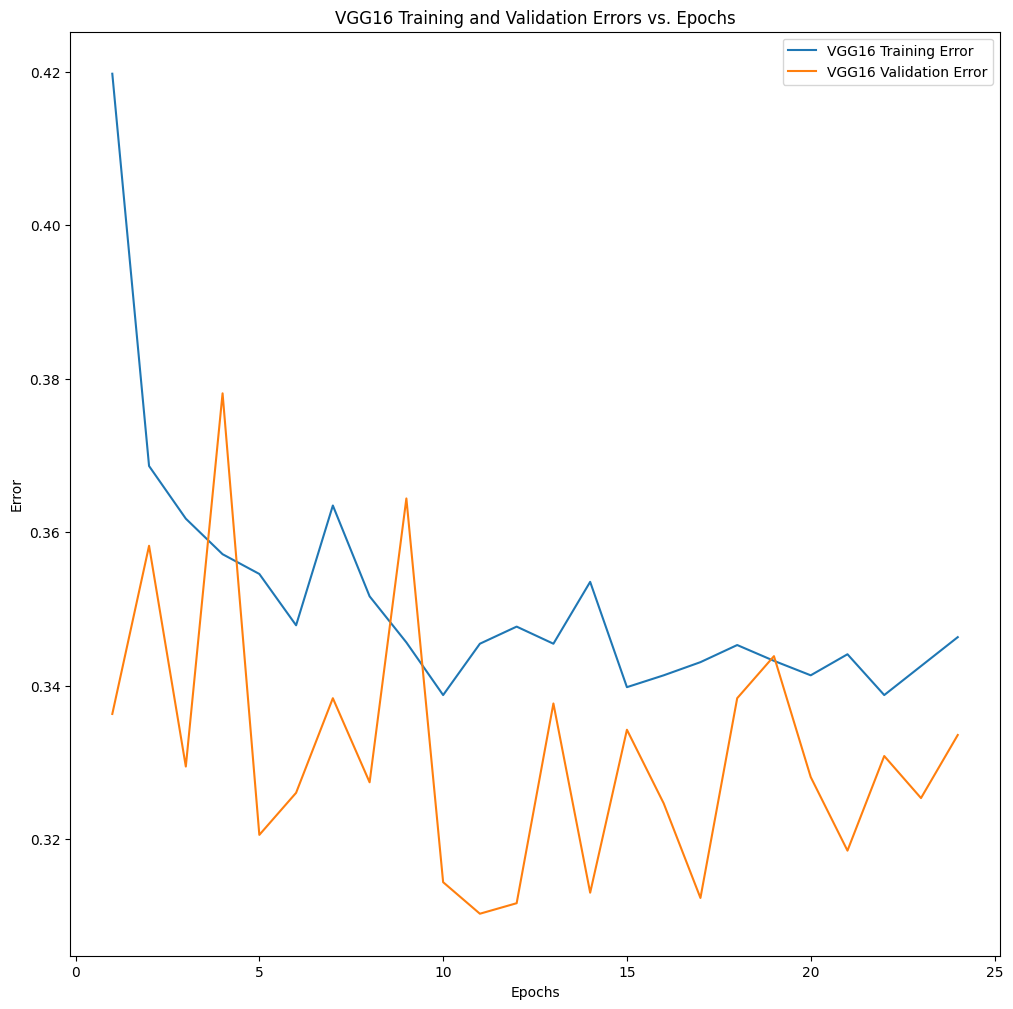

183/183 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step
VGG16 TRAINING Scores:
	Precision: 0.7292643805260339
	Recall: 0.690566037735849
	F1 Score: 0.6334740436386327
	AUC: 0.8520310420940199
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step
VGG16 TESTING Scores:
	Precision: 0.5808951970532699
	Recall: 0.6200657894736842
	F1 Score: 0.5371091421887434
	AUC: 0.7940686799579638
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step
VGG16 VALIDATION Scores:
	Precision: 0.7156439537730991
	Recall: 0.686986301369863
	F1 Score: 0.6282856258600598
	AUC: 0.8611903866029373


In [49]:
# VGG16 plot training and validation errors vs. epochs
vgg_train_acc = np.array(history_vgg.history['accuracy'])
vgg_val_acc = np.array(history_vgg.history['val_accuracy'])
vgg_train_error = 1 - vgg_train_acc
vgg_val_error = 1 - vgg_val_acc
vgg_epochs = np.arange(1, len(vgg_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(vgg_epochs, vgg_train_error, label='VGG16 Training Error')
plt.plot(vgg_epochs, vgg_val_error, label='VGG16 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("VGG16 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
vgg_Y_train_probs = vgg_fm.predict(X_train)

vgg_Y_train_true = np.argmax(Y_train, axis=1)
vgg_Y_train_pred = np.argmax(vgg_Y_train_probs, axis=1)

vgg_train_precision = precision_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_recall = recall_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_f1 = f1_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_auc = roc_auc_score(Y_train, vgg_Y_train_probs, average='weighted', multi_class='ovr')

print("VGG16 TRAINING Scores:")
print(f"\tPrecision: {vgg_train_precision}")
print(f"\tRecall: {vgg_train_recall}")
print(f"\tF1 Score: {vgg_train_f1}")
print(f"\tAUC: {vgg_train_auc}")

# testing Precision, Recall, AUC, F1 Score
vgg_Y_test_probs = vgg_fm.predict(X_test)

vgg_Y_test_true = np.argmax(Y_test, axis=1)
vgg_Y_test_pred = np.argmax(vgg_Y_test_probs, axis=1)

vgg_test_precision = precision_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_recall = recall_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_f1 = f1_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_auc = roc_auc_score(Y_test, vgg_Y_test_probs, average='weighted', multi_class='ovr')

print("VGG16 TESTING Scores:")
print(f"\tPrecision: {vgg_test_precision}")
print(f"\tRecall: {vgg_test_recall}")
print(f"\tF1 Score: {vgg_test_f1}")
print(f"\tAUC: {vgg_test_auc}")

# validation Precision, Recall, AUC, F1 Score
vgg_Y_val_probs = vgg_fm.predict(X_val)

vgg_Y_val_true = np.argmax(Y_val, axis=1)
vgg_Y_val_pred = np.argmax(vgg_Y_val_probs, axis=1)

vgg_val_precision = precision_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_recall = recall_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_f1 = f1_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_auc = roc_auc_score(Y_val, vgg_Y_val_probs, average='weighted', multi_class='ovr')

print("VGG16 VALIDATION Scores:")
print(f"\tPrecision: {vgg_val_precision}")
print(f"\tRecall: {vgg_val_recall}")
print(f"\tF1 Score: {vgg_val_f1}")
print(f"\tAUC: {vgg_val_auc}")

Transfer Learning v
- Report training, validation, and Test Precision, Recall, AUC, and F1 score for those models
- Is there a model that clearly outperforms others?
- Remember that this is a multi-class classification problem

MY ANSWER:
- Based on the outputted scores, I would say that NO MODEL CLEARLY OUTPERFORMS out of the others
- After going through the metrics, ResNet50 got better scores on 7/12 metrics (Training Precision, Validation Precision, Training Recall, Validation Recall, Training F1, Validation F1, Training AUC)
- ResNet101 got better scores on 3/12 metrics (Testing Precision, Testing F1, and Validation AUC)
- EfficientNetB0 did best on one metric (Testing AUC)
- VGG16 did best on one metric (Testing Recall)
- If going on the idea that ResNet50 did better on 7/12 (the majority) of the metrics then maybe it is clear, but based off the NUMBERS it is not
- All the numbers for the metrics were relatively close to eachother, showing that each model had relatively the same performance
- For example, the closest knit numbers are for Testing F1 (0.55, 0.57, 0.56, and 0.53 -> RN50, RN101, EFN, VGG)
- - The metric with the largest range is Validation F1 (0.76, 0.75, 0.69, 0.62 -> RN50, RN101, EFN, VGG)
- - I'm pointing this out to show that the largest range is only 0.14, showing that all these models were all close to each other
- So there is no CLEAR model that performed best
- On top of all this, despite the fact ResNet50 did better on 7/12 total metrics, ResNet101 did better on 2/4 TESTING metrics
- - Based on this, I could say that ResNet101 performed better because it generalized better based on the testing scores
- - In fact, ResNet50 did not get the best score for any of the testing metrics. EfficientNetB0 did best on Testing AUC and VGG16 did best on Testing Recall
- So to answer the actual question the project asks: no model clearly outperforms out of the others